# **CIS 5190 - IMG2GPS Final Project**

# 0. Prerequisites

## 0.1 Installing and importing dependencies




In [ ]:
!pip install geopy
!pip install datasets
!pip install torch torchvision datasets
!pip install huggingface_hub
!pip install transformers
!pip install tqdm
!pip install matplotlib
!pip install optuna
!pip install albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.7 MB/s eta 0:00:00


In [ ]:
from datasets import load_dataset, Image, concatenate_datasets

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.models import EfficientNet_B0_Weights
from torch.utils.data import DataLoader, Dataset
from transformers import AutoImageProcessor, AutoModelForImageClassification
from huggingface_hub import PyTorchModelHubMixin, snapshot_download
from PIL import Image
import os
import numpy as np

import matplotlib.pyplot as plt

import torch.optim as optim
from geopy.distance import geodesic
from torch.optim.lr_scheduler import StepLR

import albumentations as A
from albumentations.pytorch import ToTensorV2

from pyproj import Proj

In [ ]:
import os
from google.colab import drive

drive.mount('/content/drive')

# 2. Define your Drive project folder
DRIVE_BASE_PATH = '/content/drive/MyDrive/CIS5190_Final_Project'
VISUALS_PATH = os.path.join(DRIVE_BASE_PATH, 'visuals')
MODELS_PATH = os.path.join(DRIVE_BASE_PATH, 'models')

# Create the directories if they don't exist
os.makedirs(VISUALS_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)

Mounted at /content/drive


## 0.3 Device Configuration

In [ ]:
if torch.cuda.is_available():
  device = torch.device("cuda")
else:
  device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


# 1. Data

## 1.1 Downloading the train, val and test dataset

In [ ]:
# Load in the datasets
dataset_train1 = load_dataset("gracech1/combined-penn-engineering-geo-location", split="train")
dataset_val1 = load_dataset("gracech1/combined-penn-engineering-geo-location", split="validation")
dataset_test1 = load_dataset("gracech1/combined-penn-engineering-geo-location", split="test")

dataset_train2 = load_dataset("isaacyan/CIS5190_4copies_dataset", split="train").rename_column("Latitude", "latitude")
dataset_train2 = dataset_train2.rename_column("Longitude", "longitude")
dataset_val2 = load_dataset("isaacyan/CIS5190_4copies_dataset", split="test").rename_column("Latitude", "latitude")
dataset_val2 = dataset_val2.rename_column("Longitude", "longitude")

dataset_test3 = load_dataset("gydou/released_img", split="train").rename_column("Latitude", "latitude")
dataset_test3 = dataset_test3.rename_column("Longitude", "longitude")
dataset_test4 = load_dataset("gydou/5190_Spring_Final_Hidden_Data", split="test").rename_column("Latitude", "latitude")
dataset_test4 = dataset_test4.rename_column("Longitude", "longitude")

README.md:   0%|          | 0.00/583 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/24 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/24 [00:00<?, ?it/s]

data/train-00000-of-00024.parquet:   0%|          | 0.00/401M [00:00<?, ?B/s]

data/train-00001-of-00024.parquet:   0%|          | 0.00/396M [00:00<?, ?B/s]

...

data/test-00000-of-00004.parquet:   0%|          | 0.00/466M [00:00<?, ?B/s]

data/test-00001-of-00004.parquet:   0%|          | 0.00/346M [00:00<?, ?B/s]

data/test-00002-of-00004.parquet:   0%|          | 0.00/402M [00:00<?, ?B/s]

data/test-00003-of-00004.parquet:   0%|          | 0.00/465M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/300 [00:00<?, ? examples/s]

In [ ]:
dataset_train = concatenate_datasets([dataset_train1, dataset_train2])
dataset_val = concatenate_datasets([dataset_val1, dataset_val2])
dataset_test = concatenate_datasets([dataset_test1, dataset_test3, dataset_test4])

In [ ]:
# Check the info about the datasets
print(dataset_train)
print(dataset_val)
print(dataset_test)

Dataset({
    features: ['image', 'latitude', 'longitude'],
    num_rows: 5317
})
Dataset({
    features: ['image', 'latitude', 'longitude'],
    num_rows: 1050
})
Dataset({
    features: ['image', 'latitude', 'longitude'],
    num_rows: 681
})


## 1.2 Custom Dataset Class

In [ ]:
from pyproj import Proj
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
import albumentations as A
import torchvision.transforms as transforms
from albumentations.pytorch import ToTensorV2

class GPSImageDataset(Dataset):
    def __init__(self, hf_dataset, transform=None, e_min=None, n_min=None):
        self.hf_dataset = hf_dataset
        self.transform = transform

        # Initialize UTM projection for Philadelphia
        self.utm_proj = Proj(proj='utm', zone=18, ellps='WGS84', preserve_units=False)

        # Extract all lat/lon arrays to compute UTM
        lats = np.array(self.hf_dataset['latitude'])
        lons = np.array(self.hf_dataset['longitude'])

        # Convert all to UTM
        eastings, northings = self.utm_proj(lons, lats)
        self.eastings = eastings
        self.northings = northings

        # Compute block origin from the dataset if not provided
        self.e_min = e_min if e_min is not None else np.min(eastings)
        self.n_min = n_min if n_min is not None else np.min(northings)

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        # Get image directly from hf_dataset
        image = self.hf_dataset[idx]['image']

        # Apply transform
        if self.transform:
            if isinstance(self.transform, A.Compose):
                image_np = np.array(image)
                augmented = self.transform(image=image_np)
                image_tensor = augmented['image']
            else:
                image_tensor = self.transform(image)
        else:
            image_tensor = transforms.ToTensor()(image)

        # Get normalized coordinates (local UTM meters)
        # Subtract the minimum easting/northing to get relative coordinates
        target = torch.tensor([
            self.eastings[idx] - self.e_min,
            self.northings[idx] - self.n_min
        ], dtype=torch.float32)

        return image_tensor, target

## 1.3 Dataloaders and visualizing the data

In [ ]:
# Dataset Transforms

transform = A.Compose([
    # Set the required size and apply scale variance
    A.RandomResizedCrop(size=(224, 224), scale=(0.7, 1.0), p=1.0),

    # Affine/Perspective transformation
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.Perspective(scale=(0.05, 0.1), p=0.5),

    # Lighting & Gamma transformations
    A.RandomBrightnessContrast(brightness_limit=0.4, contrast_limit=0.4, p=0.5),
    A.RandomGamma(gamma_limit=(80, 120), p=0.3),
    A.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1, p=0.3),
    A.ToGray(p=0.1),

    # Subtle Weather Effects (Rain & Fog)
    A.RandomRain(brightness_coefficient=0.9, drop_length=10, p=0.05),
    A.RandomFog(p=0.05),

    # Simulated Downsampling
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 5)),
        A.MotionBlur(blur_limit=(3, 5)),
    ], p=0.3),

    # Standard Normalization
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
# Dataset Instantiation

# Create the training dataset
train_dataset = GPSImageDataset(hf_dataset=dataset_train, transform=transform)
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=8)

# Retrieve the origin point from the training set
easting_min = train_dataset.e_min
northing_min = train_dataset.n_min

# Create val and test sets
val_dataset = GPSImageDataset(
    hf_dataset=dataset_val, transform=inference_transform,
    e_min=easting_min, n_min=northing_min
)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=8)

test_dataset = GPSImageDataset(
    hf_dataset=dataset_test, transform=inference_transform,
    e_min=easting_min, n_min=northing_min
)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=8)

In [ ]:
# Verify loading
for images, gps_coords in train_dataloader:
    print(images.size(), gps_coords.size())
    break

torch.Size([16, 3, 224, 224]) torch.Size([16, 2])


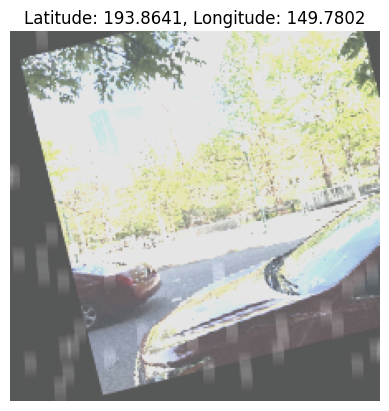

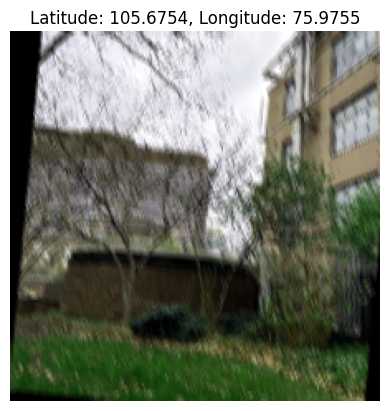

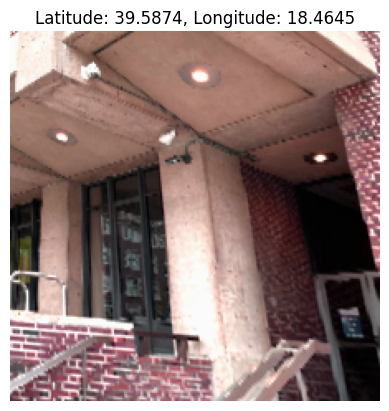

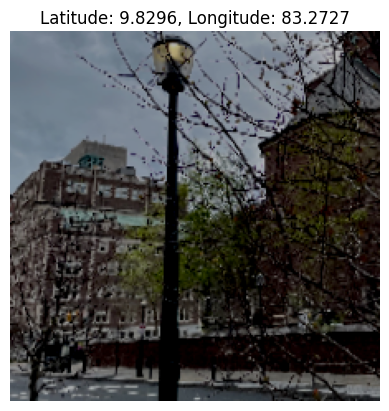

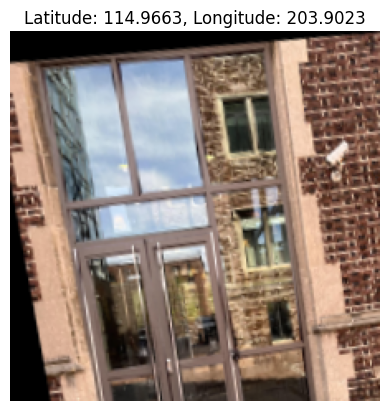

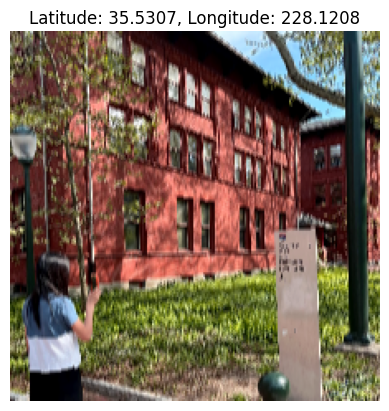

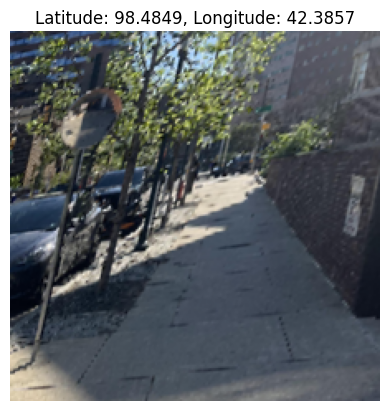

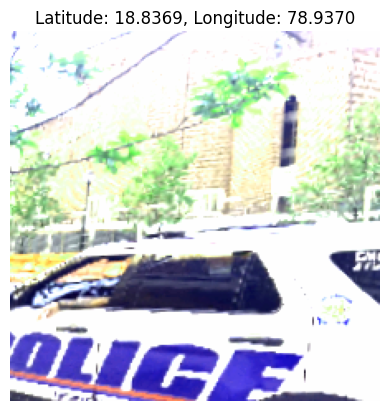

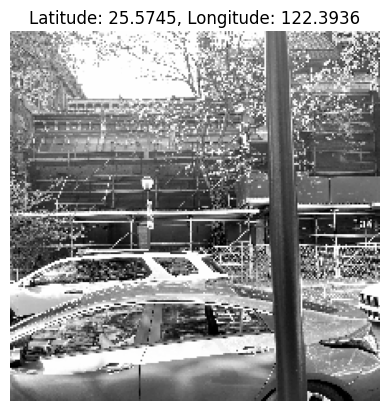

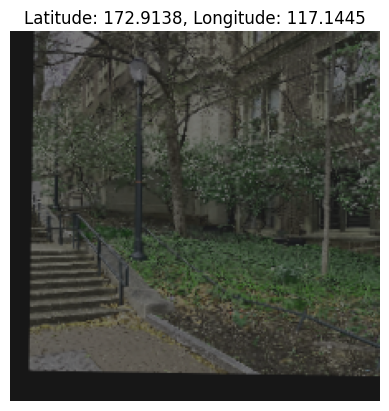

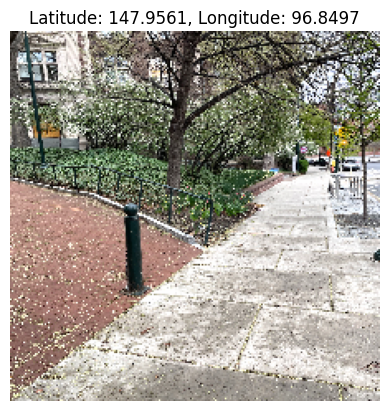

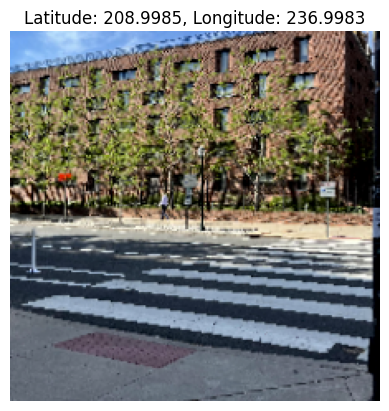

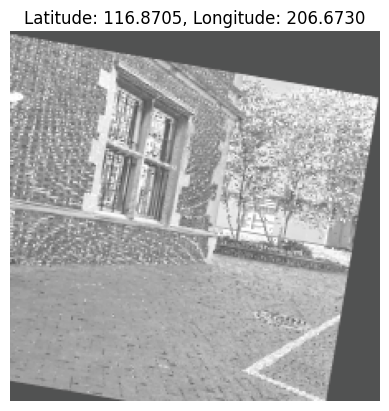

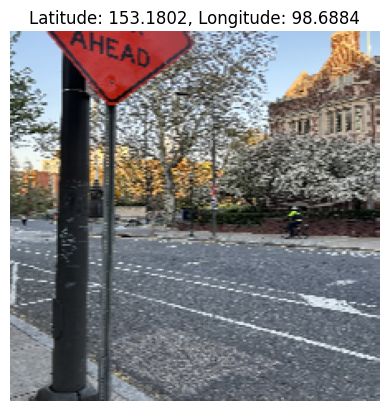

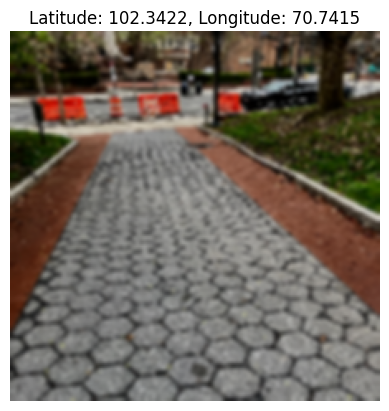

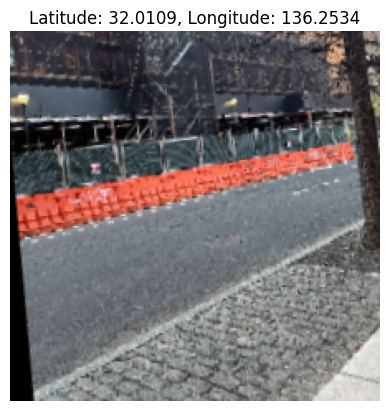

In [ ]:
# Data Visualizations

def denormalize(tensor, mean, std):
    mean = np.array(mean)
    std = np.array(std)
    tensor = tensor.numpy().transpose((1, 2, 0))  # Convert from C x H x W to H x W x C
    tensor = std * tensor + mean  # Denormalize
    tensor = np.clip(tensor, 0, 1)  # Clip to keep pixel values between 0 and 1
    return tensor

data_iter = iter(train_dataloader)
images, gps_coords = next(data_iter)  # Get a batch of images and labels

# Denormalize the first image in the batch for display
itr = 0
for im in images:
  image = denormalize(im, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

  # Plot the image
  plt.imshow(image)
  plt.title(f'Latitude: {gps_coords[itr][0].item():.4f}, Longitude: {gps_coords[itr][1].item():.4f}')
  plt.axis('off')
  plt.show()
  itr += 1

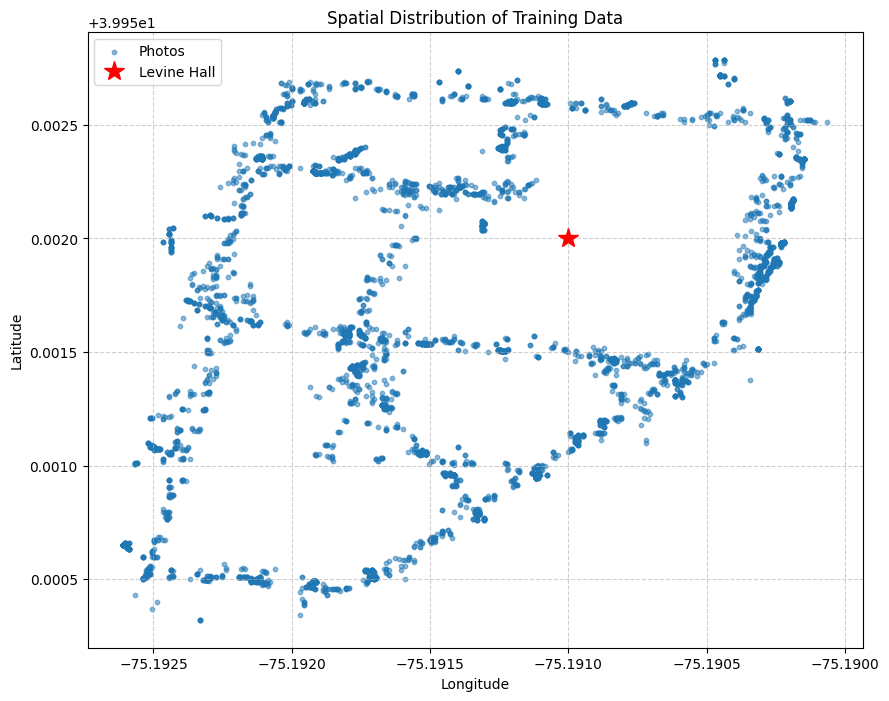

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_gps_distribution(hf_dataset):
    lats = hf_dataset['latitude']
    lons = hf_dataset['longitude']

    plt.figure(figsize=(10, 8))

    # Using a hexbin or scatter with low alpha helps see density
    plt.scatter(lons, lats, c='#1f77b4', s=10, alpha=0.5, label='Photos')

    plt.title("Spatial Distribution of Training Data")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True, linestyle='--', alpha=0.6)

    # Adding a red star for a known landmark (e.g., Levine Hall)
    # helps you orient the map
    plt.plot(-75.191, 39.952, 'r*', markersize=15, label='Levine Hall')

    plt.legend()
    plt.show()

# Run it
plot_gps_distribution(dataset_train)

# 2. Model Design and Training

## 2.1 Custom Model Class & Haversine Loss

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, size, dropout_p=0.2):
        super().__init__()
        self.fc = nn.Linear(size, size)
        self.bn = nn.BatchNorm1d(size)
        self.gelu = nn.GELU()
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, x):
        residual = x
        out = self.fc(x)
        out = self.bn(out)
        out = self.gelu(out)
        out = self.dropout(out)
        return out + residual

class EfficientNetGPS(nn.Module):
  def __init__(self, num_classes=2):
    super(EfficientNetGPS, self).__init__()

    # Backbone: EfficientNetB0
    self.backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

    # Readout: Custom Linear Model with Residual Block
    in_features = self.backbone.classifier[1].in_features

    self.backbone.classifier = nn.Sequential(
      nn.Dropout(p=0.27),
      nn.Linear(in_features, 512),
      nn.BatchNorm1d(512),
      nn.GELU(),
      ResidualBlock(512, 0.2),
      nn.Linear(512, 128),
      nn.GELU(),
      nn.Dropout(p=0.1),
      nn.Linear(128, 2)
    )

  def forward(self, x):
    if self.training:
      return self.backbone(x)

    else:
      # TTA: Testing Time Augmentation
      # Original View
      out_orig = self.backbone(x)

      # Zoomed View
      x_zoom = torch.nn.functional.interpolate(
          x[:, :, 16:-16, 16:-16], size=(224, 224), mode='bilinear'
      )
      out_zoom = self.backbone(x_zoom)

      # Brightness Boost
      x_bright = torch.clamp(x * 1.15, min=-3.0, max=3.0)
      out_bright = self.backbone(x_bright)

      # Average the 3 views
      return (out_orig + out_zoom + out_bright) / 3


  def save_model(self, save_path):
    torch.save(self.state_dict(), save_path)

## 2.2 Training Loop

In [ ]:
import os
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import time
import torch
import numpy as np

def training_loop(EPOCHS, model, optimizer, scheduler, criterion, train_loader, val_loader, device):
    print("--- Starting Training ---")
    best_val_dist = float('inf')

    # Create directory for visuals
    os.makedirs('visuals', exist_ok=True)

    history = {
        'train_loss': [],
        'val_loss': [],
        'avg_dist': []
    }

    # Retrieve UTM constants from the dataset
    e_min = train_loader.dataset.e_min
    n_min = train_loader.dataset.n_min
    utm_proj = train_loader.dataset.utm_proj

    for epoch in range(EPOCHS):
        start_time = time.time()

        # Training Phase
        model.train()
        train_loss = 0.0
        train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]', leave=False)

        for data, targets in train_bar:
            data, targets = data.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * data.size(0)
            train_bar.set_postfix(loss=f"{loss.item():.4f}")

        avg_train_loss = train_loss / len(train_loader.dataset)

        # Validation & Visualization
        model.eval()
        val_loss = 0.0
        total_dist = 0.0

        all_preds = []
        all_actuals = []

        val_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Val]', leave=False)

        with torch.no_grad():
            for data, targets in val_bar:
                data, targets = data.to(device), targets.to(device)
                scores = model(data)

                loss = criterion(scores, targets)
                val_loss += loss.item() * data.size(0)

                # Store for visualization
                all_preds.append(scores.cpu().numpy())
                all_actuals.append(targets.cpu().numpy())

                # Distance calculation
                batch_dist = torch.sqrt(torch.sum((scores - targets) ** 2, dim=1))
                total_dist += batch_dist.sum().item()
                val_bar.set_postfix(dist=f"{batch_dist.mean().item():.2f}m")

        avg_val_loss = val_loss / len(val_loader.dataset)
        avg_val_dist = total_dist / len(val_loader.dataset)

        # Generate Progress Plot
        # Concatenate results for plotting
        preds_np = np.concatenate(all_preds)
        actuals_np = np.concatenate(all_actuals)

        # Denormalize to Global Lat/Lon
        p_lon, p_lat = utm_proj(preds_np[:, 0] + e_min, preds_np[:, 1] + n_min, inverse=True)
        a_lon, a_lat = utm_proj(actuals_np[:, 0] + e_min, actuals_np[:, 1] + n_min, inverse=True)

        plt.figure(figsize=(10, 6))
        # Plot lines first so they are in the background
        for i in range(len(a_lat)):
            plt.plot([a_lon[i], p_lon[i]], [a_lat[i], p_lat[i]], color='gray', linewidth=0.3, alpha=0.4)

        plt.scatter(a_lon, a_lat, label='Actual', color='#1f77b4', s=15, alpha=0.7)
        plt.scatter(p_lon, p_lat, label='Predicted', color='#d62728', s=15, alpha=0.7)

        plt.title(f'Epoch {epoch+1} | Avg Error: {avg_val_dist:.2f}m')
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        plt.legend()

        # Save frame directly to Drive
        plot_filename = os.path.join(VISUALS_PATH, f'epoch_sgd_{epoch+1:03d}.png')
        plt.savefig(plot_filename, dpi=120)
        plt.close()

        # Checkpointing
        scheduler.step()
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['avg_dist'].append(avg_val_dist)

        print(f'Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Dist: {avg_val_dist:.2f}m')

        # Save periodic checkpoint
        if (epoch+1) % 5 == 0:
            checkpoint_name = os.path.join(MODELS_PATH, f"model_epoch_sg_{str(epoch+1).zfill(2)}.pth")
            torch.save(model.state_dict(), checkpoint_name)

        # Save best model
        if avg_val_dist < best_val_dist:
            best_val_dist = avg_val_dist
            best_model_path = os.path.join(MODELS_PATH, 'best_sgd_model.pth')
            torch.save(model.state_dict(), best_model_path)
            print(f"   -> New Record! Best model saved to Drive: {avg_val_dist:.2f}m")

    print(f"\nTraining Complete. All files saved to: {DRIVE_BASE_PATH}")
    return model, history

## 2.3 AdamW Training

In [ ]:
import time
import torch
import warnings
import logging

warnings.filterwarnings("ignore", category=UserWarning)
os.environ['PYTHONWARNINGS'] = 'ignore'

# Initialization
model = EfficientNetGPS().to(device)

# Loss Function
criterion = torch.nn.SmoothL1Loss(beta=0.1)

# Optimizer Parameter Grouping for EfficientNet
head_params = list(model.backbone.classifier[2].parameters())
backbone_params = [p for n, p in model.backbone.named_parameters() if 'classifier.2' not in n]

# Optmizer & Differential Learning Rates
optimizer = torch.optim.AdamW([
    {'params': backbone_params, 'lr': 6.5e-5},
    {'params': head_params, 'lr': 6.5e-4}
], weight_decay=1e-5)

# Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25)

# Execute Training Loop
trained_model, history = training_loop(
    25,
    model,
    optimizer,
    scheduler,
    criterion,
    train_dataloader,
    val_dataloader,
    device
)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 145MB/s]


--- Starting Training ---


Epoch 1/25 [Train]:   0%|          | 0/333 [00:00<?, ?it/s]

Epoch 1/25 [Val]:   0%|          | 0/66 [00:00<?, ?it/s]

...

Epoch 24/25 [Val]:   0%|          | 0/66 [00:00<?, ?it/s]

Epoch 24/25 | Train Loss: 22.2373 | Val Loss: 13.9162 | Dist: 22.07m


Epoch 25/25 [Train]:   0%|          | 0/333 [00:00<?, ?it/s]

Epoch 25/25 [Val]:   0%|          | 0/66 [00:00<?, ?it/s]

Epoch 25/25 | Train Loss: 22.2073 | Val Loss: 13.0729 | Dist: 20.91m
   -> New Record! Best model saved to Drive: 20.91m

Training Complete. All files saved to: /content/drive/MyDrive/CIS5190_Final_Project


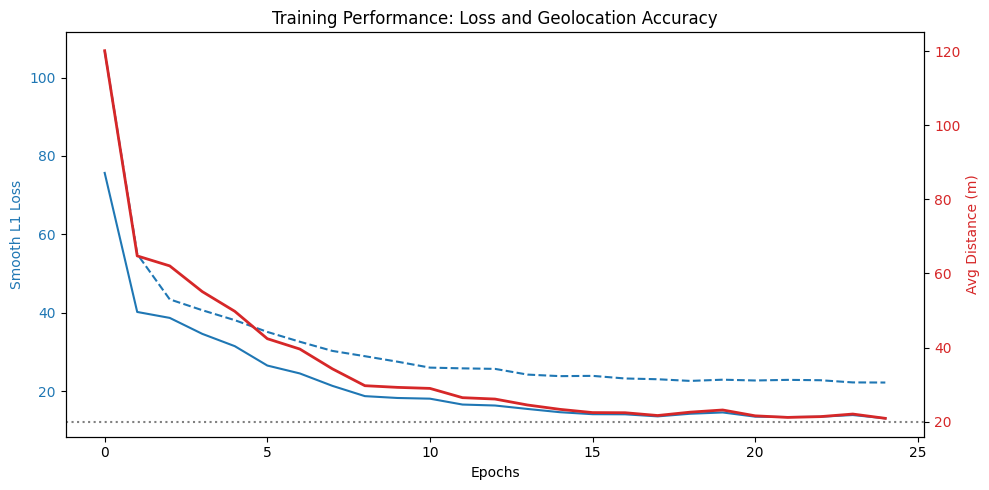

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Plot Loss on left axis
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Smooth L1 Loss', color='tab:blue')
    ax1.plot(history['train_loss'], label='Train Loss', color='tab:blue', linestyle='--')
    ax1.plot(history['val_loss'], label='Val Loss', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    # Plot Distance on right axis
    ax2 = ax1.twinx()
    ax2.set_ylabel('Avg Distance (m)', color='tab:red')
    ax2.plot(history['avg_dist'], label='Distance', color='tab:red', linewidth=2)
    ax2.tick_params(axis='y', labelcolor='tab:red')

    # Goal line
    ax2.axhline(y=20, color='gray', linestyle=':', label='Target (20m)')

    plt.title('Training Performance: Loss and Geolocation Accuracy')
    fig.tight_layout()
    plt.show()

plot_history(history)

In [ ]:
print(history)

{'train_loss': [106.85709706827149, 54.9810074036207, 43.42678400814163, 40.65806187358323, 38.11927878562952, 35.12194563281117, 32.614449224638854, 30.27723117517712, 28.92606581766309, 27.52750989703368, 26.012560664520063, 25.823233638330805, 25.691403695867546, 24.232344364254505, 23.839094416683096, 23.90824256984502, 23.24192072158248, 23.047310157447285, 22.62227578025934, 22.93171109071638, 22.72994186619473, 22.888844166838723, 22.79736408372111, 22.237340800134852, 22.207334392519627], 'val_loss': [75.6827342296782, 40.21183851696196, 38.695118844168526, 34.62610055106027, 31.484125304449172, 26.543210016886395, 24.526014153616767, 21.36236675262451, 18.73740634918213, 18.267063981919062, 18.09111485254197, 16.591646850222634, 16.346897007170178, 15.467827651614234, 14.635306772504533, 14.13038027990432, 14.100761724199568, 13.574074249267579, 14.243683368137905, 14.57620001293364, 13.501775987715948, 13.403835118611653, 13.482614756992884, 13.91616527557373, 13.072858217330

## 2.3 SGD Training (SWATS)

Here, we are applying SWATS to find the true minimum for our dataset

In [ ]:
warnings.filterwarnings("ignore", category=UserWarning)
logging.getLogger("torch.utils.data.dataloader").setLevel(logging.ERROR)

# Load the best AdamW model
model.load_state_dict(torch.load(os.path.join(MODELS_PATH, 'best_model.pth')))
model.to(device)

# Optimizer Parameter Grouping for EfficientNet
head_params = list(model.backbone.classifier[2].parameters())
backbone_params = [p for n, p in model.backbone.named_parameters() if 'classifier.2' not in n]

# Optimizer & Differential Learning Rates
optimizer = torch.optim.SGD([
    {'params': backbone_params, 'lr': 1.3e-4},
    {'params': head_params, 'lr': 1.3e-3}
], momentum=0.9, weight_decay=1e-4, nesterov=True)


# Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# Execute Training Loop
trained_model2, history2 = training_loop(
    10,
    model,
    optimizer,
    scheduler,
    criterion,
    train_dataloader,
    val_dataloader,
    device
)

--- Starting Training ---


Epoch 1/10 [Train]:   0%|          | 0/333 [00:00<?, ?it/s]

Epoch 1/10 [Val]:   0%|          | 0/66 [00:00<?, ?it/s]

Epoch 1/10 | Train Loss: 25.5708 | Val Loss: 15.6111 | Dist: 24.85m
   -> New Record! Best model saved to Drive: 24.85m


Epoch 2/10 [Train]:   0%|          | 0/333 [00:00<?, ?it/s]

...

Epoch 9/10 [Val]:   0%|          | 0/66 [00:00<?, ?it/s]

Epoch 9/10 | Train Loss: 20.0117 | Val Loss: 11.0036 | Dist: 17.53m
   -> New Record! Best model saved to Drive: 17.53m


Epoch 10/10 [Train]:   0%|          | 0/333 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/66 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 20.1986 | Val Loss: 11.4694 | Dist: 18.20m

Training Complete. All files saved to: /content/drive/MyDrive/CIS5190_Final_Project


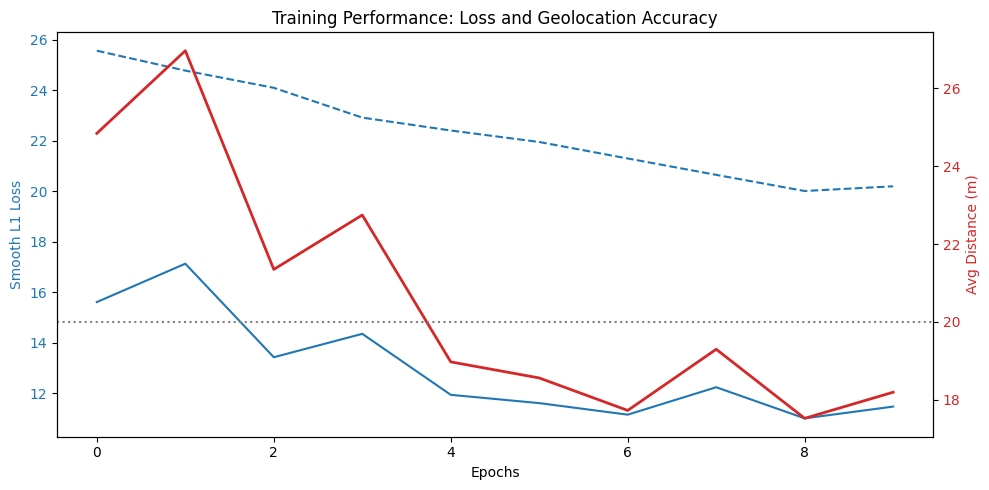

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Plot Loss on left axis
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Smooth L1 Loss', color='tab:blue')
    ax1.plot(history['train_loss'], label='Train Loss', color='tab:blue', linestyle='--')
    ax1.plot(history['val_loss'], label='Val Loss', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    # Plot Distance on right axis
    ax2 = ax1.twinx()
    ax2.set_ylabel('Avg Distance (m)', color='tab:red')
    ax2.plot(history['avg_dist'], label='Distance', color='tab:red', linewidth=2)
    ax2.tick_params(axis='y', labelcolor='tab:red')

    # Goal line
    ax2.axhline(y=20, color='gray', linestyle=':', label='Target (20m)')

    plt.title('Training Performance: Loss and Geolocation Accuracy')
    fig.tight_layout()
    plt.show()


plot_history(history2)

In [ ]:
print(history2)

{'train_loss': [25.57075690182838, 24.78215271722156, 24.100661432920194, 22.92038269753247, 22.40946431614659, 21.953930633642496, 21.300538527062002, 20.65143465354565, 20.01168093233824, 20.19858360936235], 'val_loss': [15.611114587329682, 17.131325376601445, 13.425568569728306, 14.352136105128697, 11.935354521615164, 11.606697703770228, 11.149271955944243, 12.236062380472818, 11.003623399280366, 11.469421949840727], 'avg_dist': [24.845352390834265, 26.96808050246466, 21.351274007161457, 22.746857038225446, 18.975252554757255, 18.562419971284413, 17.72802982875279, 19.29937999906994, 17.525047215053014, 18.19618884858631]}


# 3. Testing the model

## 3.1 Calculate the Haversine distance on the testing dataset

In [ ]:
# Evaluate the AdamW model

import torch
import numpy as np
from sklearn.metrics import mean_absolute_error

# Haversine formula
def haversine_unnormalized(preds, targets):
    # Calculate the physical distance in meters between raw Lat/Lon pairs
    R = 6371000 # Earth radius in meters
    lat1, lon1 = preds[:, 0], preds[:, 1]
    lat2, lon2 = targets[:, 0], targets[:, 1]

    phi1, phi2 = torch.deg2rad(lat1), torch.deg2rad(lat2)
    lam1, lam2 = torch.deg2rad(lon1), torch.deg2rad(lon2)

    a = torch.sin((phi2-phi1)/2)**2 + torch.cos(phi1)*torch.cos(phi2)*torch.sin((lam2-lam1)/2)**2

    return 2 * R * torch.asin(torch.sqrt(torch.clamp(a, min=0.0)))

# Initialize lists to store predictions and actual values
all_preds_latlon = []
all_actuals_latlon = []
distances = []

# Initialize the model architecture
model = EfficientNetGPS()
model.load_state_dict(torch.load('/content/drive/MyDrive/CIS5190_Final_Project/models/best_model.pth', map_location=device))
model = model.to(device)
model.eval()

# Get the UTM projection and origins from the dataloader
e_min = test_dataloader.dataset.e_min
n_min = test_dataloader.dataset.n_min
utm_proj = test_dataloader.dataset.utm_proj

with torch.no_grad():
    for images, targets in test_dataloader:
        images, targets = images.to(device), targets.to(device)

        # Output in local UTM meters
        outputs = model(images)

        # Denormalize to global UTM by adding the block's origin point back
        pred_easting = outputs[:, 0].cpu().numpy() + e_min
        pred_northing = outputs[:, 1].cpu().numpy() + n_min

        target_easting = targets[:, 0].cpu().numpy() + e_min
        target_northing = targets[:, 1].cpu().numpy() + n_min

        # Convert UTM back to Lat/Lon for evaluation
        pred_lon, pred_lat = utm_proj(pred_easting, pred_northing, inverse=True)
        target_lon, target_lat = utm_proj(target_easting, target_northing, inverse=True)

        # Format as Tensors for the Haversine function
        pred_coords = torch.tensor(np.column_stack((pred_lat, pred_lon)))
        true_coords = torch.tensor(np.column_stack((target_lat, target_lon)))

        all_preds_latlon.append(pred_coords)
        all_actuals_latlon.append(true_coords)

        # Calculate Haversine distance for the batch
        batch_dist = haversine_unnormalized(pred_coords, true_coords)
        distances.extend(batch_dist.tolist())

# Concatenate all batches
all_preds_latlon = torch.cat(all_preds_latlon).numpy()
all_actuals_latlon = torch.cat(all_actuals_latlon).numpy()

# Compute error metrics on Lat/Lon
mae = mean_absolute_error(all_actuals_latlon, all_preds_latlon)
print(f'Mean Absolute Error (in degrees): {mae:.8f}')

avg_distance = sum(distances) / len(distances)
print(f"Avg Haversine Distance: {avg_distance:.2f}m")

Mean Absolute Error (in degrees): 0.00022090
Avg Haversine Distance: 34.38m


In [ ]:
# Evaluate the SGD model

import torch
import numpy as np
from sklearn.metrics import mean_absolute_error

# Haversine formula
def haversine_unnormalized(preds, targets):
    # Calculate the physical distance in meters between raw Lat/Lon pairs
    R = 6371000 # Earth radius in meters
    lat1, lon1 = preds[:, 0], preds[:, 1]
    lat2, lon2 = targets[:, 0], targets[:, 1]

    phi1, phi2 = torch.deg2rad(lat1), torch.deg2rad(lat2)
    lam1, lam2 = torch.deg2rad(lon1), torch.deg2rad(lon2)

    a = torch.sin((phi2-phi1)/2)**2 + torch.cos(phi1)*torch.cos(phi2)*torch.sin((lam2-lam1)/2)**2

    return 2 * R * torch.asin(torch.sqrt(torch.clamp(a, min=0.0)))

# Initialize lists to store predictions and actual values
all_preds_latlon = []
all_actuals_latlon = []
distances = []

# Initialize the model architecture
model = EfficientNetGPS()
model.load_state_dict(torch.load('/content/drive/MyDrive/CIS5190_Final_Project/models/best_sgd_model.pth', map_location=device))
model = model.to(device)
model.eval()

# Get the UTM projection and origins from the dataloader
e_min = test_dataloader.dataset.e_min
n_min = test_dataloader.dataset.n_min
utm_proj = test_dataloader.dataset.utm_proj

with torch.no_grad():
    for images, targets in test_dataloader:
        images, targets = images.to(device), targets.to(device)

        # Output in local UTM meters
        outputs = model(images)

        # Denormalize to global UTM by adding the block's origin point back
        pred_easting = outputs[:, 0].cpu().numpy() + e_min
        pred_northing = outputs[:, 1].cpu().numpy() + n_min

        target_easting = targets[:, 0].cpu().numpy() + e_min
        target_northing = targets[:, 1].cpu().numpy() + n_min

        # Convert UTM back to Lat/Lon for evaluation
        pred_lon, pred_lat = utm_proj(pred_easting, pred_northing, inverse=True)
        target_lon, target_lat = utm_proj(target_easting, target_northing, inverse=True)

        # Format as Tensors for the Haversine function
        pred_coords = torch.tensor(np.column_stack((pred_lat, pred_lon)))
        true_coords = torch.tensor(np.column_stack((target_lat, target_lon)))

        all_preds_latlon.append(pred_coords)
        all_actuals_latlon.append(true_coords)

        # Calculate Haversine distance for the batch
        batch_dist = haversine_unnormalized(pred_coords, true_coords)
        distances.extend(batch_dist.tolist())

# Concatenate all batches
all_preds_latlon = torch.cat(all_preds_latlon).numpy()
all_actuals_latlon = torch.cat(all_actuals_latlon).numpy()

# Compute error metrics on Lat/Lon
mae = mean_absolute_error(all_actuals_latlon, all_preds_latlon)
print(f'Mean Absolute Error (in degrees): {mae:.8f}')

avg_distance = sum(distances) / len(distances)
print(f"Avg Haversine Distance: {avg_distance:.2f}m")

Mean Absolute Error (in degrees): 0.00019056
Avg Haversine Distance: 29.63m


## 3.2 Project the points on the map

In [ ]:
import numpy as np

# Retrieve the UTM origin and projection from the training dataset
e_min = train_dataset.e_min
n_min = train_dataset.n_min
utm_proj = train_dataset.utm_proj

# Convert UTM Local Meters -> Global UTM coordinates
preds_easting = all_preds_latlon[:, 0] + e_min
preds_northing = all_preds_latlon[:, 1] + n_min

actuals_easting = all_actuals_latlon[:, 0] + e_min
actuals_northing = all_actuals_latlon[:, 1] + n_min

# Convert Global UTM back into Latitude and Longitude
preds_lon, preds_lat = utm_proj(preds_easting, preds_northing, inverse=True)
actuals_lon, actuals_lat = utm_proj(actuals_easting, actuals_northing, inverse=True)

# Stack them together into (N, 2) arrays
all_preds_denorm = np.column_stack((preds_lat, preds_lon))
all_actuals_denorm = np.column_stack((actuals_lat, actuals_lon))

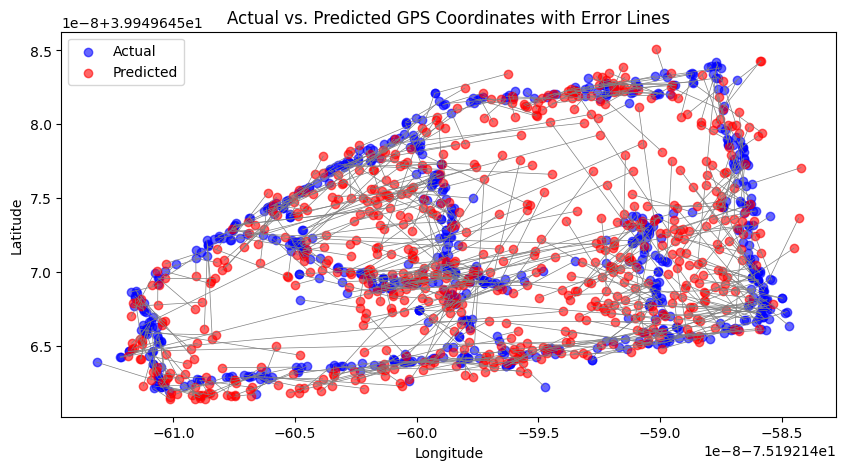

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Plot actual points
plt.scatter(all_actuals_denorm[:, 1], all_actuals_denorm[:, 0], label='Actual', color='blue', alpha=0.6)

# Plot predicted points
plt.scatter(all_preds_denorm[:, 1], all_preds_denorm[:, 0], label='Predicted', color='red', alpha=0.6)

# Draw lines connecting actual and predicted points
for i in range(len(all_actuals_denorm)):
    plt.plot(
        [all_actuals_denorm[i, 1], all_preds_denorm[i, 1]],
        [all_actuals_denorm[i, 0], all_preds_denorm[i, 0]],
        color='gray', linewidth=0.5
    )

plt.legend()
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Actual vs. Predicted GPS Coordinates with Error Lines')
plt.show()

## 3.3 Export the final model together with Local UTM to Lat/Lon conversion pipeline

In [ ]:
import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import EfficientNet_B0_Weights
from pyproj import Proj
from collections.abc import Iterable

# Calculate the conversion constants for Penn's Campus
utm_proj = Proj(proj='utm', zone=18, ellps='WGS84', preserve_units=False)
e_min, n_min = train_dataset.e_min, train_dataset.n_min
lon_orig, lat_orig = utm_proj(e_min, n_min, inverse=True)

delta = 0.01
_, n_plus = utm_proj(lon_orig, lat_orig + delta)
m_per_lat = (n_plus - n_min) / delta

e_plus, _ = utm_proj(lon_orig + delta, lat_orig)
m_per_lon = (e_plus - e_min) / delta

# The model class
class Model(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.base_model = EfficientNetGPS()
        self.register_buffer('origin', torch.tensor([0.0, 0.0], dtype=torch.float32))
        self.register_buffer('scale', torch.tensor([1.0, 1.0], dtype=torch.float32))

    def forward(self, x):
        local_meters = self.base_model(x)
        dx_easting = local_meters[:, 0]
        dy_northing = local_meters[:, 1]

        lat_offset = dy_northing / self.scale[0]
        lon_offset = dx_easting / self.scale[1]

        return torch.stack([self.origin[0] + lat_offset, self.origin[1] + lon_offset], dim=1)

    def predict(self, batch):
        self.eval() # Ensure dropout is off
        device = next(self.parameters()).device

        if isinstance(batch, torch.Tensor):
            inputs = batch.to(device)
        else:
            inputs = torch.stack(list(batch)).to(device)

        with torch.no_grad():
            preds = self.forward(inputs)
        return preds.cpu().tolist()

final_model = Model()
final_model.base_model.load_state_dict(torch.load('/content/drive/MyDrive/CIS5190_Final_Project/models/best_sgd_model.pth'))

# Inject the accurate buffers
final_model.origin.copy_(torch.tensor([lat_orig, lon_orig]))
final_model.scale.copy_(torch.tensor([m_per_lat, m_per_lon]))

# Save the model
torch.save(final_model.state_dict(), 'final_model.pt')
print(f"Exported with Origin: {lat_orig}, {lon_orig}")

Exported with Origin: 39.95032175798604, -75.19261019047501
